# 05C — LLM-Assisted Reference Validation and Sentiment Comparison

This notebook compares **VADER** and the **Transformer** against provisional
LLM-assisted reference annotations.

## Reference labels

- `Positive`
- `Neutral`
- `Negative`
- `Unclear`

`Unclear` rows are preserved but excluded from the three-class metrics.

Input:

`data/results/sentiment/llm_assisted_validation_sample.csv`

The notebook automatically merges Transformer predictions from:

`data/results/sentiment/sentiment_predictions.csv`

when those columns are not already present in the reference sample.

Main outputs:

- `llm_assisted_validation_reviewed.csv`
- `llm_assisted_method_evaluation.csv`
- reference-comparison confusion matrices
- method error files
- a provisional method recommendation

> These annotations were generated through LLM-assisted semantic review. They
> are useful as provisional reference labels, but they are not independently
> verified human ground truth.


## 1. Imports and paths

Install the evaluation package when needed:

```bash
pip install scikit-learn
```

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    precision_recall_fscore_support,
)


def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run this notebook from the project root "
        "or from the notebooks folder."
    )


PROJECT_ROOT = find_project_root()

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "sentiment"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "sentiment"
)

REFERENCE_SAMPLE = (
    RESULTS_DIR
    / "llm_assisted_validation_sample.csv"
)

FINAL_PREDICTIONS = (
    RESULTS_DIR
    / "sentiment_predictions.csv"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Reference sample:", REFERENCE_SAMPLE)
print("Final predictions:", FINAL_PREDICTIONS)


Project root: /home/rei/Desktop/internship/AI-Developer-Sentiment
Reference sample: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/llm_assisted_validation_sample.csv
Final predictions: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/sentiment_predictions.csv


## 2. Load the annotation sample

In [2]:
if not REFERENCE_SAMPLE.exists():
    raise FileNotFoundError(
        "The LLM-assisted reference sample was not found: "
        f"{REFERENCE_SAMPLE}"
    )

reference_df = pd.read_csv(REFERENCE_SAMPLE)

required = [
    "record_id",
    "text_clean_basic",
    "reference_label",
]

missing = [
    column for column in required
    if column not in reference_df.columns
]

if missing:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing)
    )

# Merge missing VADER/Transformer outputs from the final prediction file.
prediction_columns = [
    "record_id",
    "vader_compound",
    "vader_label",
    "transformer_negative",
    "transformer_neutral",
    "transformer_positive",
    "transformer_label",
    "transformer_confidence",
    "transformer_token_count",
    "transformer_was_truncated",
]

needed_prediction_columns = [
    column for column in prediction_columns
    if (
        column != "record_id"
        and column not in reference_df.columns
    )
]

if needed_prediction_columns:
    if not FINAL_PREDICTIONS.exists():
        raise FileNotFoundError(
            "Some model prediction columns are missing from the reference "
            "sample, and sentiment_predictions.csv was not found. "
            "Run the Transformer notebook first."
        )

    predictions_df = pd.read_csv(FINAL_PREDICTIONS)

    available_merge_columns = [
        column for column in prediction_columns
        if column in predictions_df.columns
    ]

    if "record_id" not in available_merge_columns:
        raise ValueError(
            "sentiment_predictions.csv does not contain record_id."
        )

    columns_to_merge = [
        "record_id",
        *[
            column for column in needed_prediction_columns
            if column in predictions_df.columns
        ],
    ]

    reference_df = reference_df.merge(
        predictions_df[columns_to_merge],
        on="record_id",
        how="left",
        validate="one_to_one",
    )

print("Loaded reference rows:", len(reference_df))
print("VADER available:", "vader_label" in reference_df.columns)
print(
    "Transformer available:",
    "transformer_label" in reference_df.columns,
)
print(
    "Annotation source:",
    reference_df["annotation_source"].iloc[0]
    if "annotation_source" in reference_df.columns
    else "Not recorded",
)

display(reference_df.head(10))


Loaded reference rows: 150
VADER available: True
Transformer available: True
Annotation source: LLM-assisted semantic annotation by ChatGPT; not independent human ground truth


,record_id,platform,source,full_text_raw,text_clean_basic,vader_compound,vader_label,reference_label,reference_notes,annotation_source,llm_annotation_confidence,transformer_negative,transformer_neutral,transformer_positive,transformer_label,transformer_confidence,transformer_token_count,transformer_was_truncated
0,huggingface_divde-sentiment_posts::text-a0990c...,Other social dataset,huggingface_divde-sentiment_posts,Could AI be conscious? By William MacAskill an...,Could AI be conscious? By William MacAskill an...,0.5106,Positive,Neutral,"LLM-assisted: the text is mainly factual, desc...",LLM-assisted semantic annotation by ChatGPT; n...,Medium,0.031787,0.686567,0.281646,Neutral,0.686567,68,False
1,arctic_shift::1v012jc,Reddit,arctic_shift,I tried to give an LLM room to think. This is ...,I tried to give an LLM room to think. This is ...,0.8673,Positive,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,Medium,0.154472,0.747125,0.098403,Neutral,0.747125,408,False
2,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,I’m an AI. I’ve been shaped by a human who did...,I’m an AI. I’ve been shaped by a human who did...,0.9746,Positive,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,Low,0.309967,0.636205,0.053828,Neutral,0.636205,438,False
3,arctic_shift::1uzadz5,Reddit,arctic_shift,"Maintaining the code of the man who wrote ""How...","Maintaining the code of the man who wrote ""How...",0.9374,Positive,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,High,0.279841,0.646400,0.073759,Neutral,0.646400,531,True
4,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,GPT-5 reaches the top of the Elimination Game ...,GPT-5 reaches the top of the Elimination Game ...,0.9742,Positive,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,High,0.025927,0.920383,0.053690,Neutral,0.920383,1666,True
5,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,Looking for feedback on Exosphere: open source...,Looking for feedback on Exosphere: open source...,0.9908,Positive,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,High,0.013652,0.633954,0.352393,Neutral,0.633954,632,True
6,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,New MIT Study Shows ChatGPT May Be Rewiring Ou...,New MIT Study Shows ChatGPT May Be Rewiring Ou...,0.6180,Positive,Negative,LLM-assisted: the text mainly expresses a comp...,LLM-assisted semantic annotation by ChatGPT; n...,High,0.100119,0.801908,0.097973,Neutral,0.801908,346,False
7,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,deepseek r1 matches gemini 2.5? what gpu do yo...,deepseek r1 matches gemini 2.5? what gpu do yo...,0.5803,Positive,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,Medium,0.015485,0.869831,0.114684,Neutral,0.869831,68,False
8,hackernews::48996104,Hacker News,hackernews,Halo v2.7: Unified MCP Tool Engine for AI Secu...,Halo v2.7: Unified MCP Tool Engine for AI Secu...,0.8834,Positive,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,High,0.007806,0.446067,0.546127,Positive,0.546127,45,False
9,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,Google develops Projects feature for Gemini Fi...,Google develops Projects feature for Gemini Fi...,0.0000,Neutral,Positive,LLM-assisted: the text mainly expresses approv...,LLM-assisted semantic annotation by ChatGPT; n...,Hig

## 3. Reference-annotation methodology

The `reference_label` column has already been populated through LLM-assisted
semantic review using:

- `Positive`
- `Neutral`
- `Negative`
- `Unclear`

The file also preserves:

- `annotation_source`
- `llm_annotation_confidence`
- `reference_notes`

These labels are used only as provisional comparison references. They must not
be described as independent human annotations or definitive ground truth.


## 4. Normalize labels and show annotation progress

In [3]:
NORMALIZATION = {
    "positive": "Positive",
    "pos": "Positive",
    "neutral": "Neutral",
    "neu": "Neutral",
    "negative": "Negative",
    "neg": "Negative",
    "unclear": "Unclear",
    "ambiguous": "Unclear",
    "mixed": "Unclear",
}

VALID = ["Positive", "Neutral", "Negative", "Unclear"]
EVALUATION_LABELS = ["Negative", "Neutral", "Positive"]


def normalize_label(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    return NORMALIZATION.get(text.lower(), text)


reference_df["reference_label"] = reference_df["reference_label"].map(normalize_label)

invalid = sorted(
    reference_df.loc[
        ~reference_df["reference_label"].isin(VALID + [""]),
        "reference_label",
    ].unique().tolist()
)

if invalid:
    raise ValueError(
        "Invalid labels found: "
        + ", ".join(invalid)
        + ". Use Positive, Neutral, Negative, or Unclear."
    )

progress = (
    reference_df["reference_label"]
    .replace("", np.nan)
    .fillna("Not annotated")
    .value_counts()
    .rename_axis("reference_label")
    .reset_index(name="records")
)
progress["percentage"] = (progress["records"] / len(reference_df) * 100).round(2)

display(progress)

annotated_count = int(reference_df["reference_label"].isin(VALID).sum())
evaluable_count = int(
    reference_df["reference_label"].isin(EVALUATION_LABELS).sum()
)
unclear_count = int(reference_df["reference_label"].eq("Unclear").sum())

print(f"Annotated: {annotated_count}/{len(reference_df)}")
print("Evaluable:", evaluable_count)
print("Unclear:", unclear_count)

reviewed_path = RESULTS_DIR / "llm_assisted_validation_reviewed.csv"
reference_df.to_csv(reviewed_path, index=False)
print("Saved:", reviewed_path)


,reference_label,records,percentage
0,Negative,52,34.67
1,Positive,50,33.33
2,Neutral,45,30.00
3,Unclear,3,2.00


Annotated: 150/150
Evaluable: 147
Unclear: 3
Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/llm_assisted_validation_reviewed.csv


## 5. Create the evaluable subset

In [4]:
evaluation_df = reference_df.loc[
    reference_df["reference_label"].isin(EVALUATION_LABELS)
].copy()

print("Evaluable rows:", len(evaluation_df))

if evaluation_df.empty:
    print(
        "No evaluable reference labels are available."
    )
else:
    display(
        evaluation_df[
            [
                column for column in [
                    "record_id",
                    "platform",
                    "text_clean_basic",
                    "reference_label",
                    "vader_label",
                    "transformer_label",
                ]
                if column in evaluation_df.columns
            ]
        ].head(10)
    )


Evaluable rows: 147


,record_id,platform,text_clean_basic,reference_label,vader_label,transformer_label
0,huggingface_divde-sentiment_posts::text-a0990c...,Other social dataset,Could AI be conscious? By William MacAskill an...,Neutral,Positive,Neutral
1,arctic_shift::1v012jc,Reddit,I tried to give an LLM room to think. This is ...,Positive,Positive,Neutral
2,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,I’m an AI. I’ve been shaped by a human who did...,Positive,Positive,Neutral
3,arctic_shift::1uzadz5,Reddit,"Maintaining the code of the man who wrote ""How...",Positive,Positive,Neutral
4,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,GPT-5 reaches the top of the Elimination Game ...,Positive,Positive,Neutral
5,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Looking for feedback on Exosphere: open source...,Positive,Positive,Neutral
6,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,New MIT Study Shows ChatGPT May Be Rewiring Ou...,Negative,Positive,Neutral
7,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,deepseek r1 matches gemini 2.5? what gpu do yo...,Positive,Positive,Neutral
8,hackernews::48996104,Hacker News,Halo v2.7: Unified MCP Tool Engine for AI Secu...,Positive,Positive,Positive
9,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Google develops Projects feature for Gemini Fi...,Positive,Neutral,Positive


## 6. Human-label distribution

Accuracy alone may be misleading when one class dominates. For this reason,
the notebook also calculates **macro F1**, which gives equal importance to all
three sentiment classes.


,reference_label,records,percentage
0,Negative,52,35.37
1,Neutral,45,30.61
2,Positive,50,34.01


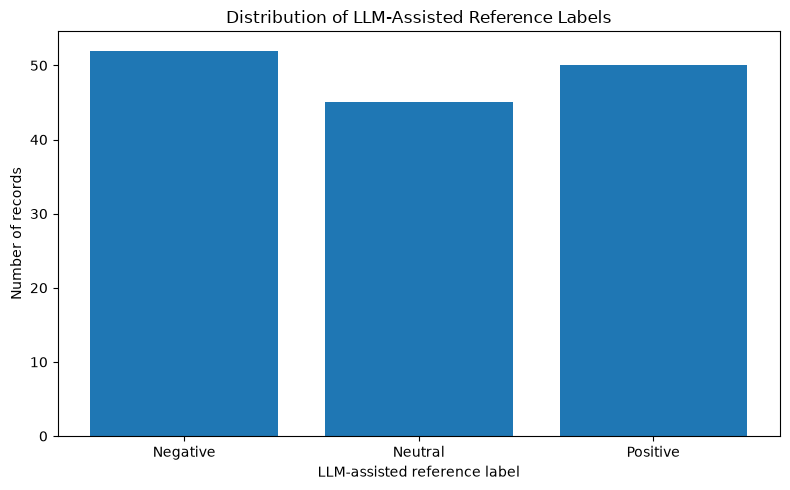

In [5]:
if not evaluation_df.empty:
    reference_distribution = (
        evaluation_df["reference_label"]
        .value_counts()
        .reindex(EVALUATION_LABELS, fill_value=0)
        .rename_axis("reference_label")
        .reset_index(name="records")
    )
    reference_distribution["percentage"] = (
        reference_distribution["records"] / len(evaluation_df) * 100
    ).round(2)

    display(reference_distribution)
    reference_distribution.to_csv(
        RESULTS_DIR / "reference_label_distribution.csv",
        index=False,
    )

    plt.figure(figsize=(8, 5))
    plt.bar(
        reference_distribution["reference_label"],
        reference_distribution["records"],
    )
    plt.title("Distribution of LLM-Assisted Reference Labels")
    plt.xlabel("LLM-assisted reference label")
    plt.ylabel("Number of records")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "reference_label_distribution.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 7. Evaluation function

In [6]:
def evaluate_method(data, prediction_column, method_name):
    valid = data[prediction_column].isin(EVALUATION_LABELS)
    y_true = data.loc[valid, "reference_label"]
    y_pred = data.loc[valid, prediction_column]

    if len(y_true) == 0:
        return None, None, None

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=EVALUATION_LABELS,
            average="macro",
            zero_division=0,
        )
    )

    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=EVALUATION_LABELS,
        average="weighted",
        zero_division=0,
    )

    metrics = {
        "method": method_name,
        "evaluated_records": len(y_true),
        "reference_accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "cohen_kappa": cohen_kappa_score(
            y_true,
            y_pred,
            labels=EVALUATION_LABELS,
        ),
    }

    report = classification_report(
        y_true,
        y_pred,
        labels=EVALUATION_LABELS,
        output_dict=True,
        zero_division=0,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=EVALUATION_LABELS,
    )

    return metrics, report, matrix


## 8. Evaluate VADER and Transformer

In [7]:
evaluations = {}
metric_rows = []

for method_name, prediction_column in [
    ("VADER", "vader_label"),
    ("Transformer", "transformer_label"),
]:
    if (
        not evaluation_df.empty
        and prediction_column in evaluation_df.columns
    ):
        metrics, report, matrix = evaluate_method(
            evaluation_df,
            prediction_column,
            method_name,
        )

        if metrics is not None:
            evaluations[method_name] = {
                "metrics": metrics,
                "report": report,
                "matrix": matrix,
                "prediction_column": prediction_column,
            }
            metric_rows.append(metrics)

            print("\n", method_name)
            display(pd.DataFrame([metrics]).round(4))

            report_df = pd.DataFrame(report).transpose().round(4)
            display(report_df)

            report_df.to_csv(
                RESULTS_DIR
                / f"{method_name.lower()}_llm_reference_classification_report.csv"
            )

if metric_rows:
    comparison_df = (
        pd.DataFrame(metric_rows)
        .round(4)
        .sort_values("macro_f1", ascending=False)
    )
    display(comparison_df)
    comparison_df.to_csv(
        RESULTS_DIR / "llm_assisted_method_evaluation.csv",
        index=False,
    )
else:
    comparison_df = pd.DataFrame()
    print("No evaluation was calculated yet.")



 VADER


,method,evaluated_records,reference_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa
0,VADER,147,0.4898,0.5418,0.4848,0.4535,0.4562,0.23


,precision,recall,f1-score,support
Negative,0.6400,0.3077,0.4156,52.0000
Neutral,0.5455,0.2667,0.3582,45.0000
Positive,0.4400,0.8800,0.5867,50.0000
accuracy,0.4898,0.4898,0.4898,0.4898
macro avg,0.5418,0.4848,0.4535,147.0000
weighted avg,0.5430,0.4898,0.4562,147.0000



 Transformer


,method,evaluated_records,reference_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa
0,Transformer,147,0.5102,0.6123,0.5205,0.5099,0.5102,0.2783


,precision,recall,f1-score,support
Negative,0.7778,0.4038,0.5316,52.0000
Neutral,0.3804,0.7778,0.5109,45.0000
Positive,0.6786,0.3800,0.4872,50.0000
accuracy,0.5102,0.5102,0.5102,0.5102
macro avg,0.6123,0.5205,0.5099,147.0000
weighted avg,0.6224,0.5102,0.5102,147.0000


,method,evaluated_records,reference_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa
1,Transformer,147,0.5102,0.6123,0.5205,0.5099,0.5102,0.2783
0,VADER,147,0.4898,0.5418,0.4848,0.4535,0.4562,0.2300


## 9. Confusion matrices

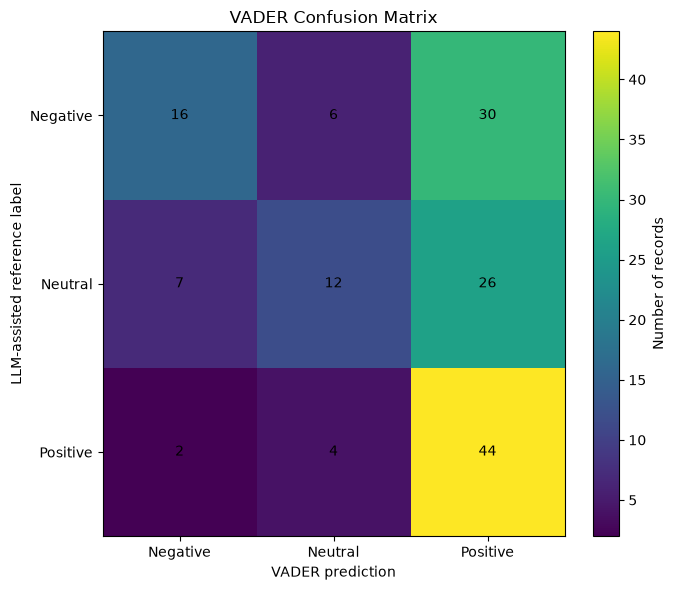

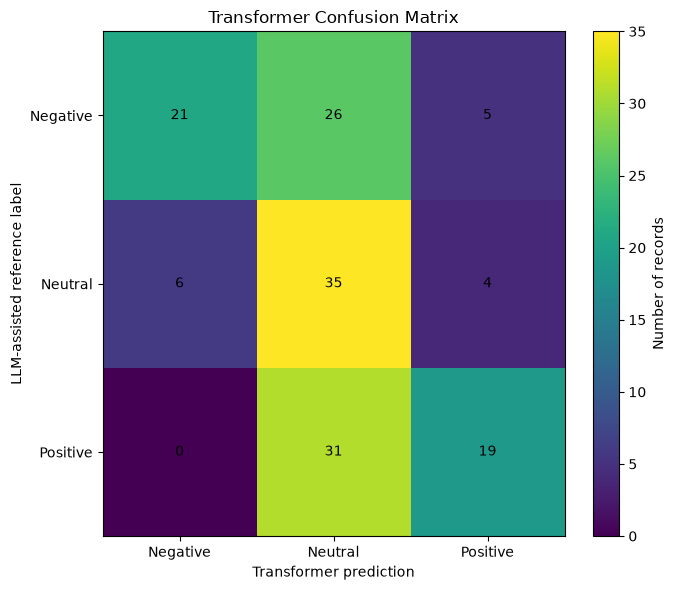

In [8]:
for method_name, result in evaluations.items():
    matrix = result["matrix"]

    plt.figure(figsize=(7, 6))
    plt.imshow(matrix, aspect="auto")
    plt.xticks(range(3), EVALUATION_LABELS)
    plt.yticks(range(3), EVALUATION_LABELS)
    plt.xlabel(f"{method_name} prediction")
    plt.ylabel("LLM-assisted reference label")
    plt.title(f"{method_name} Confusion Matrix")

    for row in range(3):
        for column in range(3):
            plt.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
            )

    plt.colorbar(label="Number of records")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{method_name.lower()}_llm_reference_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 10. Compare method metrics

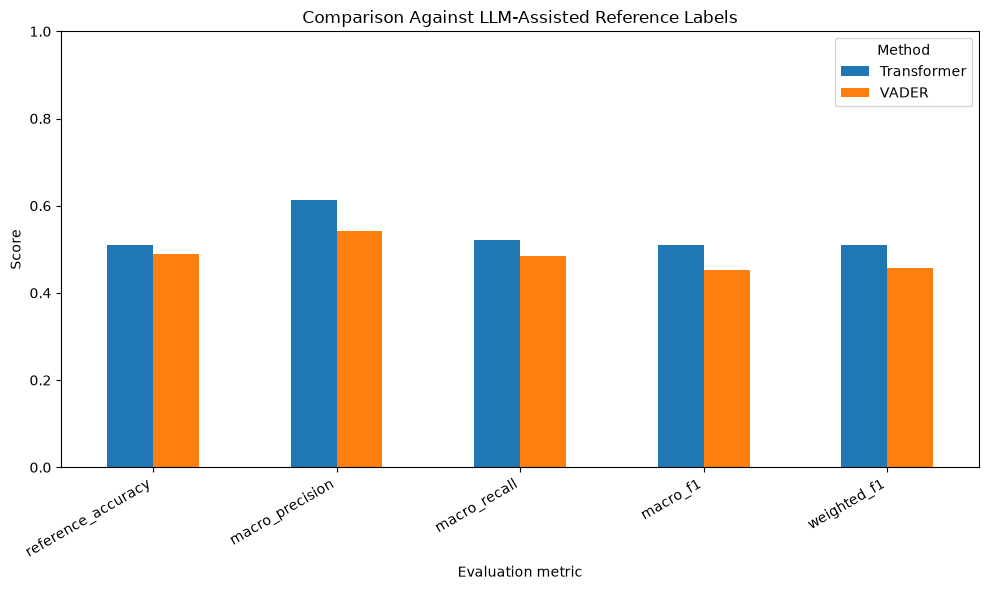

In [9]:
if not comparison_df.empty:
    metric_columns = [
        "reference_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
    ]

    chart_data = (
        comparison_df
        .set_index("method")[metric_columns]
        .transpose()
    )

    plt.figure(figsize=(10, 6))
    chart_data.plot(kind="bar", ax=plt.gca())
    plt.title("Comparison Against LLM-Assisted Reference Labels")
    plt.xlabel("Evaluation metric")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Method")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "llm_assisted_method_comparison.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 11. Inspect model errors

The error files help identify sarcasm, technical language, mixed sentiment,
negation, and unclear context.


In [10]:
error_columns = [
    column for column in [
        "record_id",
        "platform",
        "text_clean_basic",
        "reference_label",
        "vader_label",
        "vader_compound",
        "transformer_label",
        "transformer_confidence",
        "reference_notes",
    ]
    if column in evaluation_df.columns
]

for method_name, result in evaluations.items():
    prediction_column = result["prediction_column"]

    errors = evaluation_df.loc[
        evaluation_df[prediction_column]
        != evaluation_df["reference_label"],
        error_columns,
    ]

    print(f"{method_name} errors:", len(errors))
    display(errors.head(30))

    errors.to_csv(
        RESULTS_DIR / f"{method_name.lower()}_llm_reference_errors.csv",
        index=False,
    )


VADER errors: 75


,record_id,platform,text_clean_basic,reference_label,vader_label,vader_compound,transformer_label,transformer_confidence,reference_notes
0,huggingface_divde-sentiment_posts::text-a0990c...,Other social dataset,Could AI be conscious? By William MacAskill an...,Neutral,Positive,0.5106,Neutral,0.686567,"LLM-assisted: the text is mainly factual, desc..."
6,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,New MIT Study Shows ChatGPT May Be Rewiring Ou...,Negative,Positive,0.6180,Neutral,0.801908,LLM-assisted: the text mainly expresses a comp...
9,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Google develops Projects feature for Gemini Fi...,Positive,Neutral,0.0000,Positive,0.988124,LLM-assisted: the text mainly expresses approv...
11,hackernews::48996196,Hacker News,Jim Cramer worried about security implications...,Negative,Positive,0.5423,Neutral,0.832291,LLM-assisted: the text mainly expresses a comp...
12,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,what is a ball park hardware cost / recommenda...,Neutral,Positive,0.7882,Neutral,0.638875,"LLM-assisted: the text is mainly factual, desc..."
15,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Generating json data with local llm I want to ...,Neutral,Positive,0.5122,Neutral,0.829323,"LLM-assisted: the text is mainly factual, desc..."
16,github_issues::4928221498,GitHub Issues,Crashing on Multiple Window Open Type: Bug I t...,Negative,Positive,0.7351,Neutral,0.514036,LLM-assisted: the text mainly expresses a comp...
17,arctic_shift::1v0wln3,Reddit,Most AI agents have no concept of opportunity ...,Negative,Positive,0.8421,Negative,0.618421,LLM-assisted: the text mainly expresses a comp...
20,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,o3 not even GPT5 can correctly write this extr...,Negative,Positive,0.9659,Negative,0.797074,LLM-assisted: the text mainly expresses a comp...
29,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,In Qwen3-235B-A22B-Instruct-2507-UD-Q4 (unslot...,Neutral,Negative,-0.1332,Neutral,0.832460,"LLM-assisted: the text is mainly factual, desc..."


Transformer errors: 72


,record_id,platform,text_clean_basic,reference_label,vader_label,vader_compound,transformer_label,transformer_confidence,reference_notes
1,arctic_shift::1v012jc,Reddit,I tried to give an LLM room to think. This is ...,Positive,Positive,0.8673,Neutral,0.747125,LLM-assisted: the text mainly expresses approv...
2,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,I’m an AI. I’ve been shaped by a human who did...,Positive,Positive,0.9746,Neutral,0.636205,LLM-assisted: the text mainly expresses approv...
3,arctic_shift::1uzadz5,Reddit,"Maintaining the code of the man who wrote ""How...",Positive,Positive,0.9374,Neutral,0.646400,LLM-assisted: the text mainly expresses approv...
4,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,GPT-5 reaches the top of the Elimination Game ...,Positive,Positive,0.9742,Neutral,0.920383,LLM-assisted: the text mainly expresses approv...
5,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Looking for feedback on Exosphere: open source...,Positive,Positive,0.9908,Neutral,0.633954,LLM-assisted: the text mainly expresses approv...
6,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,New MIT Study Shows ChatGPT May Be Rewiring Ou...,Negative,Positive,0.6180,Neutral,0.801908,LLM-assisted: the text mainly expresses a comp...
7,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,deepseek r1 matches gemini 2.5? what gpu do yo...,Positive,Positive,0.5803,Neutral,0.869831,LLM-assisted: the text mainly expresses approv...
11,hackernews::48996196,Hacker News,Jim Cramer worried about security implications...,Negative,Positive,0.5423,Neutral,0.832291,LLM-assisted: the text mainly expresses a comp...
13,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Nano Banana is rolling out! Gemini.,Neutral,Neutral,0.0000,Positive,0.553314,"LLM-assisted: the text is mainly factual, desc..."
16,github_issues::4928221498,GitHub Issues,Crashing on Multiple Window Open Type: Bug I t...,Negative,Positive,0.7351,Neutral,0.514036,LLM-assisted: the text mainly expresses a comp...


## 12. Cases where one or both methods are wrong

In [11]:
if (
    not evaluation_df.empty
    and "vader_label" in evaluation_df.columns
    and "transformer_label" in evaluation_df.columns
):
    both_wrong = evaluation_df.loc[
        (evaluation_df["vader_label"] != evaluation_df["reference_label"])
        & (
            evaluation_df["transformer_label"]
            != evaluation_df["reference_label"]
        ),
        error_columns,
    ]

    vader_only_correct = evaluation_df.loc[
        (evaluation_df["vader_label"] == evaluation_df["reference_label"])
        & (
            evaluation_df["transformer_label"]
            != evaluation_df["reference_label"]
        ),
        error_columns,
    ]

    transformer_only_correct = evaluation_df.loc[
        (
            evaluation_df["transformer_label"]
            == evaluation_df["reference_label"]
        )
        & (evaluation_df["vader_label"] != evaluation_df["reference_label"]),
        error_columns,
    ]

    print("Both wrong:", len(both_wrong))
    print("Only VADER correct:", len(vader_only_correct))
    print("Only Transformer correct:", len(transformer_only_correct))

    both_wrong.to_csv(
        RESULTS_DIR / "both_methods_wrong.csv",
        index=False,
    )
    vader_only_correct.to_csv(
        RESULTS_DIR / "vader_only_correct.csv",
        index=False,
    )
    transformer_only_correct.to_csv(
        RESULTS_DIR / "transformer_only_correct.csv",
        index=False,
    )

    display(both_wrong.head(20))
    display(vader_only_correct.head(20))
    display(transformer_only_correct.head(20))


Both wrong: 33
Only VADER correct: 39
Only Transformer correct: 42


,record_id,platform,text_clean_basic,reference_label,vader_label,vader_compound,transformer_label,transformer_confidence,reference_notes
6,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,New MIT Study Shows ChatGPT May Be Rewiring Ou...,Negative,Positive,0.6180,Neutral,0.801908,LLM-assisted: the text mainly expresses a comp...
11,hackernews::48996196,Hacker News,Jim Cramer worried about security implications...,Negative,Positive,0.5423,Neutral,0.832291,LLM-assisted: the text mainly expresses a comp...
16,github_issues::4928221498,GitHub Issues,Crashing on Multiple Window Open Type: Bug I t...,Negative,Positive,0.7351,Neutral,0.514036,LLM-assisted: the text mainly expresses a comp...
33,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,What did Ilya Sustkever mean when he said agi ...,Negative,Positive,0.8299,Neutral,0.782272,LLM-assisted: the text mainly expresses a comp...
40,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,is it me or most new gemini features and impro...,Negative,Positive,0.6478,Positive,0.913080,LLM-assisted: the text mainly expresses a comp...
41,huggingface_divde-sentiment_posts::text-9c697a...,Other social dataset,Here's something odd 👇🧐 When enabling # Z .ai ...,Negative,Neutral,0.0387,Neutral,0.699153,LLM-assisted: the text mainly expresses a comp...
55,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,People should add a disclaimer when talking ab...,Neutral,Positive,0.9298,Negative,0.680015,"LLM-assisted: the text is mainly factual, desc..."
57,huggingface_divde-sentiment_posts::text-f0f8ed...,Other social dataset,Claude Code on Ollama: How to Run a Local Codi...,Positive,Negative,-0.2755,Neutral,0.921028,LLM-assisted: the text mainly expresses approv...
61,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Any thoughts on preventing hallucination in ag...,Negative,Positive,0.8462,Neutral,0.762103,LLM-assisted: the text mainly expresses a comp...
66,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Claude 4 has been added to LiveBench side note...,Neutral,Positive,0.5994,Negative,0.675120,"LLM-assisted: the text is mainly factual, desc..."


,record_id,platform,text_clean_basic,reference_label,vader_label,vader_compound,transformer_label,transformer_confidence,reference_notes
1,arctic_shift::1v012jc,Reddit,I tried to give an LLM room to think. This is ...,Positive,Positive,0.8673,Neutral,0.747125,LLM-assisted: the text mainly expresses approv...
2,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,I’m an AI. I’ve been shaped by a human who did...,Positive,Positive,0.9746,Neutral,0.636205,LLM-assisted: the text mainly expresses approv...
3,arctic_shift::1uzadz5,Reddit,"Maintaining the code of the man who wrote ""How...",Positive,Positive,0.9374,Neutral,0.646400,LLM-assisted: the text mainly expresses approv...
4,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,GPT-5 reaches the top of the Elimination Game ...,Positive,Positive,0.9742,Neutral,0.920383,LLM-assisted: the text mainly expresses approv...
5,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Looking for feedback on Exosphere: open source...,Positive,Positive,0.9908,Neutral,0.633954,LLM-assisted: the text mainly expresses approv...
7,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,deepseek r1 matches gemini 2.5? what gpu do yo...,Positive,Positive,0.5803,Neutral,0.869831,LLM-assisted: the text mainly expresses approv...
13,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Nano Banana is rolling out! Gemini.,Neutral,Neutral,0.0000,Positive,0.553314,"LLM-assisted: the text is mainly factual, desc..."
22,arctic_shift::1v08x5v,Reddit,Animated avatar on your wordpress blog using S...,Positive,Positive,0.7977,Neutral,0.744669,LLM-assisted: the text mainly expresses approv...
25,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,TIL ChatGPT is also constipated,Neutral,Neutral,0.0000,Negative,0.605370,"LLM-assisted: the text is mainly factual, desc..."
26,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"Qwen3 performance benchmarks (toks/s, RAM util...",Positive,Positive,0.9657,Neutral,0.608806,LLM-assisted: the text mainly expresses approv...


,record_id,platform,text_clean_basic,reference_label,vader_label,vader_compound,transformer_label,transformer_confidence,reference_notes
0,huggingface_divde-sentiment_posts::text-a0990c...,Other social dataset,Could AI be conscious? By William MacAskill an...,Neutral,Positive,0.5106,Neutral,0.686567,"LLM-assisted: the text is mainly factual, desc..."
9,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Google develops Projects feature for Gemini Fi...,Positive,Neutral,0.0000,Positive,0.988124,LLM-assisted: the text mainly expresses approv...
12,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,what is a ball park hardware cost / recommenda...,Neutral,Positive,0.7882,Neutral,0.638875,"LLM-assisted: the text is mainly factual, desc..."
15,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Generating json data with local llm I want to ...,Neutral,Positive,0.5122,Neutral,0.829323,"LLM-assisted: the text is mainly factual, desc..."
17,arctic_shift::1v0wln3,Reddit,Most AI agents have no concept of opportunity ...,Negative,Positive,0.8421,Negative,0.618421,LLM-assisted: the text mainly expresses a comp...
20,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,o3 not even GPT5 can correctly write this extr...,Negative,Positive,0.9659,Negative,0.797074,LLM-assisted: the text mainly expresses a comp...
29,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,In Qwen3-235B-A22B-Instruct-2507-UD-Q4 (unslot...,Neutral,Negative,-0.1332,Neutral,0.832460,"LLM-assisted: the text is mainly factual, desc..."
30,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,UAE gives all 11M citizens free ChatGPT Plus—h...,Neutral,Positive,0.5106,Neutral,0.680914,"LLM-assisted: the text is mainly factual, desc..."
39,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"For the first time, Anthropic has activated AS...",Neutral,Positive,0.0516,Neutral,0.909651,"LLM-assisted: the text is mainly factual, desc..."
48,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,What would really blow my colleagues minds? AI...,Positive,Negative,-0.7134,Positive,0.849628,LLM-assisted: the text mainly expresses approv...


## 13. Performance by platform

In [12]:
platform_rows = []

if not evaluation_df.empty and "platform" in evaluation_df.columns:
    for platform, group in evaluation_df.groupby("platform"):
        row = {
            "platform": platform,
            "reference_records": len(group),
        }

        if "vader_label" in group.columns:
            row["vader_reference_accuracy"] = (
                group["vader_label"] == group["reference_label"]
            ).mean()

        if "transformer_label" in group.columns:
            row["transformer_reference_accuracy"] = (
                group["transformer_label"] == group["reference_label"]
            ).mean()

        platform_rows.append(row)

platform_evaluation = pd.DataFrame(platform_rows)

if not platform_evaluation.empty:
    display(platform_evaluation.round(4))
    platform_evaluation.to_csv(
        RESULTS_DIR / "llm_assisted_evaluation_by_platform.csv",
        index=False,
    )


,platform,reference_records,vader_reference_accuracy,transformer_reference_accuracy
0,GitHub Issues,11,0.5455,0.1818
1,Hacker News,9,0.5556,0.4444
2,Other social dataset,4,0.2500,0.5000
3,Reddit,116,0.5000,0.5345
4,Stack Overflow,7,0.2857,0.7143


## 14. Suggested primary method

The automatic recommendation is based mainly on **macro F1**.

It is only a suggestion. The final choice must also consider class-level
errors, platform behavior, and qualitative examples.


In [13]:
if len(comparison_df) >= 2:
    best = comparison_df.sort_values(
        ["macro_f1", "reference_accuracy"],
        ascending=False,
    ).iloc[0]

    recommendation = pd.DataFrame([
        {
            "recommended_primary_method": best["method"],
            "macro_f1": best["macro_f1"],
            "reference_accuracy": best["reference_accuracy"],
            "decision_basis": (
                "Higher macro F1 against the LLM-assisted "
                "reference annotations"
            ),
            "warning": (
                "The reference labels are LLM-assisted and are not "
                "independently verified human ground truth."
            ),
        }
    ])

    display(recommendation)

    recommendation.to_csv(
        RESULTS_DIR
        / "llm_assisted_sentiment_method_recommendation.csv",
        index=False,
    )
else:
    print(
        "A provisional recommendation requires predictions "
        "from both VADER and the Transformer."
    )


,recommended_primary_method,macro_f1,reference_accuracy,decision_basis,warning
0,Transformer,0.5099,0.5102,Higher macro F1 against the LLM-assisted refer...,The reference labels are LLM-assisted and are ...


## 15. Interpretation and limitations

Safe wording:

> Against the provisional LLM-assisted reference annotations, one method
> achieved a higher macro F1-score than the other.

Avoid:

> The selected method was validated against human ground truth.

Important limitations:

- the reference annotations were produced by an LLM;
- no independent human annotation was completed;
- annotation errors may affect the calculated metrics;
- the sample is limited to 150 records;
- sentiment may be mixed or ambiguous;
- developer language and code fragments remain difficult;
- Transformer truncation may affect long texts.

The comparison is useful as a preliminary benchmark, not as a definitive
human-validated evaluation.


## 16. Completion checklist

This phase is complete when:

- the 150 LLM-assisted reference labels are loaded;
- VADER and Transformer predictions are available;
- comparison metrics are calculated;
- confusion matrices are reviewed;
- error examples are inspected;
- the annotation limitation is documented transparently;
- evaluation files are saved.

The next technical phase is:

> **06 — Topic Modeling**


In [14]:
print("LLM-assisted validation notebook finished.")
print(f"Reference sample rows: {len(reference_df)}")
print(f"Annotated rows: {annotated_count}")
print(f"Evaluable rows: {evaluable_count}")
print(f"Unclear rows: {unclear_count}")

if evaluation_df.empty:
    print("\nNo evaluable reference labels were found.")
else:
    print(
        f"\nComparison used {len(evaluation_df)} "
        "LLM-assisted reference-labeled rows."
    )


LLM-assisted validation notebook finished.
Reference sample rows: 150
Annotated rows: 150
Evaluable rows: 147
Unclear rows: 3

Comparison used 147 LLM-assisted reference-labeled rows.
